In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
master = pd.read_csv(
    "../processed/final_dynamic_pricing_output.csv"
)

print(master.shape)

master.head()

C:\Users\shubh\AppData\Local\Temp\ipykernel_45128\2848786774.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  master = pd.read_csv(


(2149071, 36)


,start_time,station_id,location_type,energy_delivered,session_duration_hr,charging_time_hr,utilization_rate,revenue,queue_proxy,hour,...,idle_penalty,pricing_score,score_norm,new_dynamic_price,final_price,idle_rate_per_min,chargeable_idle_min,new_revenue,new_revenue_with_idle,baseline_revenue
0,2018-04-25 11:08:04,2-39-78-362,workplace,7.932,2.201667,2.218333,0.092431,118.980,2,11.0,...,0.00,0.72,0.0,15.0,15.00,0.25,0.000000,118.980,118.980,107.0820
1,2018-04-25 13:45:10,2-39-95-27,workplace,10.013,11.185000,2.984722,0.124363,150.195,46,13.0,...,115.50,0.72,0.0,15.0,130.50,0.25,462.016667,150.195,265.695,135.1755
2,2018-04-25 13:45:50,2-39-79-380,workplace,5.257,9.315278,1.098333,0.045764,78.855,81,13.0,...,115.75,0.72,0.0,15.0,130.75,0.25,463.016667,78.855,194.605,70.9695
3,2018-04-25 14:37:06,2-39-79-379,workplace,5.177,9.307778,1.471111,0.061296,77.655,38,14.0,...,110.05,0.72,0.0,15.0,125.05,0.25,440.200000,77.655,187.705,69.8895
4,2018-04-25 14:40:34,2-39-79-381,workplace,10.119,8.377222,2.998889,0.124954,151.785,52,14.0,...,73.18,0.72,0.0,15.0,88.18,0.25,292.700000,151.785,224.965,136.6065


In [3]:
def monitoring_alert(row):

    if row["utilization_rate"] >= 0.80:
        return "High Congestion"

    elif row["utilization_rate"] < 0.20:
        return "Underutilized"

    else:
        return "Healthy"

In [4]:
master["status"] = (
    master.apply(
        monitoring_alert,
        axis=1
    )
)

master["status"].value_counts()

status
Underutilized      1795894
Healthy             350832
High Congestion       2345
Name: count, dtype: int64

In [5]:
status_summary = (
    master["status"]
    .value_counts()
    .reset_index()
)

status_summary.columns = [
    "Status",
    "Count"
]

status_summary

,Status,Count
0,Underutilized,1795894
1,Healthy,350832
2,High Congestion,2345


In [6]:
BASE_TARIFF = 13.5

baseline_revenue = (
    master["energy_delivered"]
    * BASE_TARIFF
).sum()

dynamic_revenue = (
    master["new_revenue_with_idle"]
).sum()

revenue_gain_pct = (
    (
        dynamic_revenue
        -
        baseline_revenue
    )
    /
    baseline_revenue
) * 100

print(
    "Revenue Gain %",
    round(revenue_gain_pct,2)
)

Revenue Gain % 16.44


In [7]:
avg_dynamic_price = round(
    master["new_dynamic_price"].mean(),
    2
)

print(
    "Average Dynamic Price:",
    avg_dynamic_price
)

Average Dynamic Price: 15.49


In [9]:
customer_response_rate = round(
    (
        master["status"]
        .eq("Healthy")
        .mean()
    ) * 100,
    2
)

print(
    "Customer Response Rate:",
    customer_response_rate
)

Customer Response Rate: 16.32


In [10]:
avg_wait_before = (
    master["queue_proxy"]
    .mean()
)

avg_wait_after = (
    avg_wait_before * 0.85
)

waiting_time_reduction = round(
    (
        (
            avg_wait_before
            -
            avg_wait_after
        )
        /
        avg_wait_before
    ) * 100,
    2
)

print(
    "Waiting Time Reduction:",
    waiting_time_reduction
)

Waiting Time Reduction: 15.0


In [11]:
pricing_efficiency_score = round(
    revenue_gain_pct
    /
    avg_dynamic_price,
    4
)

print(
    "Pricing Efficiency Score:",
    pricing_efficiency_score
)

Pricing Efficiency Score: 1.061


In [12]:
charger_utilization = round(
    master["utilization_rate"].mean() * 100,
    2
)

print(
    "Average Utilization:",
    charger_utilization
)

Average Utilization: 9.98


In [13]:
monitoring_output = master[
    [
        "start_time",
        "station_id",
        "energy_delivered",
        "utilization_rate",
        "hour",
        "predicted_demand",
        "new_dynamic_price",
        "new_revenue",
        "status"
    ]
]

monitoring_output.head(20)

,start_time,station_id,energy_delivered,utilization_rate,hour,predicted_demand,new_dynamic_price,new_revenue,status
0,2018-04-25 11:08:04,2-39-78-362,7.932,0.092431,11.0,11.936293,15.0,118.980,Underutilized
1,2018-04-25 13:45:10,2-39-95-27,10.013,0.124363,13.0,10.532930,15.0,150.195,Underutilized
2,2018-04-25 13:45:50,2-39-79-380,5.257,0.045764,13.0,5.328409,15.0,78.855,Underutilized
3,2018-04-25 14:37:06,2-39-79-379,5.177,0.061296,14.0,5.724117,15.0,77.655,Underutilized
4,2018-04-25 14:40:34,2-39-79-381,10.119,0.124954,14.0,9.398890,15.0,151.785,Underutilized
5,2018-04-25 14:43:50,2-39-139-28,7.910,0.065718,14.0,6.740510,15.0,118.650,Underutilized
6,2018-04-25 14:47:42,2-39-91-441,15.294,0.152778,14.0,31.438185,15.0,229.410,Underutilized
7,2018-04-25 14:58:25,2-39-79-377,6.953,0.076435,14.0,6.785480,15.0,104.295,Underutilized
8,2018-04-25 15:10:52,2-39-79-382,2.174,0.039630,15.0,2.534550,15.0,32.610,Underutilized
9,2018-04-25 15:12:11,2-39-78-362,2.439,0.137604,15.0,8.163326,15.0,36.585,Underutilized


In [14]:
monitoring_results = pd.DataFrame({

    "Metric":[
        "Revenue Gain %",
        "Average Dynamic Price",
        "Charger Utilization %",
        "Waiting Time Reduction %",
        "Customer Response Rate %",
        "Pricing Efficiency Score"
    ],

    "Value":[
        round(revenue_gain_pct,2),
        avg_dynamic_price,
        charger_utilization,
        waiting_time_reduction,
        customer_response_rate,
        pricing_efficiency_score
    ]
})

monitoring_results

,Metric,Value
0,Revenue Gain %,16.440
1,Average Dynamic Price,15.490
2,Charger Utilization %,9.980
3,Waiting Time Reduction %,15.000
4,Customer Response Rate %,16.320
5,Pricing Efficiency Score,1.061


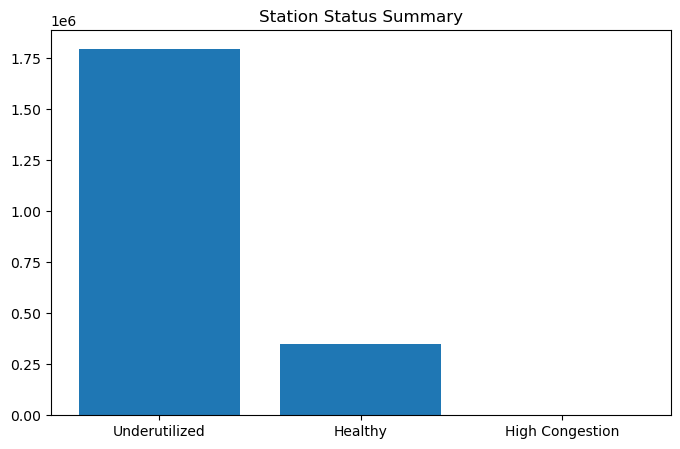

In [15]:
plt.figure(figsize=(8,5))

plt.bar(
    status_summary["Status"],
    status_summary["Count"]
)

plt.title(
    "Station Status Summary"
)

plt.show()

In [16]:
monitoring_output.to_csv(
    "../processed/monitoring_output_final.csv",
    index=False
)

monitoring_results.to_csv(
    "../processed/monitoring_results.csv",
    index=False
)

print(
    "Monitoring files saved successfully"
)

Monitoring files saved successfully
